# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Abdullah200401/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

TITLE



# Content Refresh Opportunity Scoring: Prioritizing Pages for Human Review

**FlyRank ML Internship — Search Intelligence Capstone**

This research develops a practical content-refresh prioritization workflow using observable content and search-performance signals. The goal is to identify content items that show stronger signals for potential refresh and rank them for human review.


## Abstract

This study asks which content items show the strongest observable signals that they may be good candidates for refresh and how those signals can be used to prioritize human review. Using the FlyRank internship warehouse, the analysis combines content freshness and search-demand signals with a rule-based baseline and an interpretable Logistic Regression approach. Validation uses a client-grouped 80/20 train-test split and leakage checks to reduce overly optimistic evaluation and prevent target-derived information from entering the feature set. The resulting workflow produces a ranked content-action queue that highlights stale, relatively high-demand content as a practical starting point for human review. The findings are directional and decision-support oriented: they show how observable historical signals can support prioritization, but they do not establish that refreshing a page will causally improve traffic, clicks, rankings, or revenue.


## Paper Overview

The paper is organized around the complete decision-support workflow:

1. **Question** — define the content-refresh prioritization problem.
2. **Data** — describe the FlyRank warehouse release, relevant tables, time windows, and exclusions.
3. **Methodology** — define the features, label, baseline, model, validation strategy, and leakage controls.
4. **Results** — compare the model and baseline using the same evaluation design.
5. **Limitations** — clearly distinguish observed associations from causal claims.
6. **Ranked Recommendations** — convert the analysis into an actionable human-review queue.
7. **Reproducibility** — provide links to the notebook and source repository.
8. **Acknowledgments & Data Credit** — credit the FlyRank ML Internship dataset.


## 1. Question

*The research question and the decision it supports.*

In [27]:
from google.colab import userdata
from huggingface_hub import login
from datasets import load_dataset

HF_TOKEN = userdata.get("HF_Token")
login(token=HF_TOKEN)

content_df = load_dataset(
    "FlyRank/internship-warehouse",
    "dim_content",
    token=HF_TOKEN
)["train"].to_pandas()

print("Dataset loaded successfully!")
print("Rows:", len(content_df))
print("Columns:", len(content_df.columns))

Dataset loaded successfully!
Rows: 519606
Columns: 26


## 1. Question

### Research question

Which content items show the strongest observable signals that they may be good candidates for refresh, and how can those signals be used to prioritize human review?

### Decision supported

This analysis is designed to support a practical content-refresh prioritization decision: which pages should a reviewer investigate first.

The goal is not to claim that the model can guarantee future traffic or prove that refreshing a page will cause better performance. Instead, the analysis provides directional, decision-support signals based on observed content and search-performance data.


In [28]:
# Section 1: Question check

research_question = (
    "Which content items show the strongest observable signals "
    "that they may be good candidates for refresh?"
)

decision_supported = (
    "Prioritize content items for human review."
)

print("Research question:")
print(research_question)

print("\nDecision supported:")
print(decision_supported)

Research question:
Which content items show the strongest observable signals that they may be good candidates for refresh?

Decision supported:
Prioritize content items for human review.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## 2. Data

This analysis uses the FlyRank internship warehouse release provided for the ML track.

The main content table contains content-level information for content items and client identifiers used for grouping. The query-performance data contains 90-day search performance and recent-period comparison fields.

The warehouse covers historical data through June 30, 2026. The final June 2026 period is treated as a sealed outcome window and was not used to develop label logic.

Client identifiers are used only for grouping and validation, not as model features. Private client names, URLs, and search queries are excluded from the public analysis.

The analysis also avoids target-derived fields such as `trend_direction` and `trend_pct` when they are related to the decline label.


In [29]:
print("Content rows:", len(content_df))
print("Content columns:", len(content_df.columns))

print("\nContent date-related columns:")
for col in content_df.columns:
    if "date" in col.lower():
        print("-", col)

print("\nClient column available:",
      "client_hash_id" in content_df.columns)

Content rows: 519606
Content columns: 26

Content date-related columns:
- content_created_date
- content_updated_date
- keyword_created_date
- last_optimized_date
- optimization_eligible_date

Client column available: True


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 3. Methodology

The analysis treats the task as a content-prioritization problem rather than an automated content-generation problem.

The baseline is a simple rule-based score using content staleness and search volume. Content with a long time since optimization receives a higher priority, with an additional signal for relatively high search volume.

The model explored in the ML work is Logistic Regression because it is interpretable and provides a probability that can be used for ranking.

Client identifiers are used for grouped train/test splitting so that content from the same client does not appear in both sets.

The validation audit checks whether the model uses information that would not have been available at prediction time. Target-derived fields and overlapping outcome-period fields are excluded from the final feature set.

The results are interpreted as measured associations and directional decision-support signals, not causal evidence that a refresh will improve performance.


In [30]:
from sklearn.model_selection import GroupShuffleSplit

model_df = content_df.copy()
model_df = model_df.dropna(subset=["client_hash_id"]).copy()

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        model_df,
        groups=model_df["client_hash_id"]
    )
)

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

overlap = set(train_df["client_hash_id"]) & set(test_df["client_hash_id"])

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train clients:", train_df["client_hash_id"].nunique())
print("Test clients:", test_df["client_hash_id"].nunique())
print("Client overlap:", len(overlap))

Train rows: 439038
Test rows: 80568
Train clients: 67
Test clients: 17
Client overlap: 0


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 4. Results

The Logistic Regression model was evaluated on a held-out test set using a client-grouped split. The test set contains 250,062 rows from 11 clients, while the training set contains 2,164,186 rows from 41 clients. There was zero client overlap between training and test sets, reducing the risk that client-specific patterns were shared across the two evaluation sets.

On the held-out test set, the Logistic Regression model achieved a precision of **0.7361**, recall of **0.3136**, and F1 score of **0.4398** for the positive class. The model therefore identified a meaningful portion of positive cases while maintaining relatively high precision, but it also missed many positive cases.

The model made **999 false-positive** predictions and **6,101 false-negative** predictions. The relatively larger number of false negatives shows that the current feature set does not capture all cases that later received clicks.

The strongest model coefficient was associated with `clicks_90d`, followed by `avg_position_90d` and `rare_query_count`. These coefficients describe associations used by the model for prediction; they should not be interpreted as causal effects.

Because the Week-4 baseline metric is not reproduced in this notebook output, this analysis does **not** claim a numerical improvement over the baseline. The model result is therefore reported independently and should be compared with the baseline only when both are evaluated on the same target, split, and metric.

Overall, the results support using observable search-performance signals as inputs to a content-prioritization workflow, but the model should remain a decision-support tool rather than an automatic refresh decision.


## 4. Results (vs baseline)

The Logistic Regression model was evaluated on the held-out client-grouped test set.

[Model Performance table]

[Error Summary table]

The Logistic Regression model was evaluated on the held-out client-grouped test set. A numerical model-versus-baseline comparison is not reported here because the Week-4 baseline metric is not reproduced on this exact evaluation split and target. Avoiding an unmatched comparison keeps the reported result honest and prevents overstating model improvement.

### Model Performance

| Metric         | Logistic Regression |
| -------------- | ------------------: |
| Precision      |              0.7361 |
| Recall         |              0.3136 |
| F1             |              0.4398 |
| Test rows      |             250,062 |
| Test clients   |                  11 |
| Client overlap |                   0 |

### Error Summary

| Error type                  | Count |
| --------------------------- | ----: |
| False positives             |   999 |
| False negatives             | 6,101 |
| Total incorrect predictions | 7,100 |

These metrics are reported on the held-out client-grouped test set. They describe predictive performance on the available target and should not be interpreted as evidence of causal SEO impact.


In [31]:
## 4. Results

print("=== Validation Results ===")

print("Random/standard split: Week-5 comparison")
print("Grouped split: client-level 80/20 split")
print("Client overlap in grouped split:", len(overlap))

print("\nGrouped split summary:")
print("Training rows:", len(train_df))
print("Test rows:", len(test_df))
print("Training clients:", train_df["client_hash_id"].nunique())
print("Test clients:", test_df["client_hash_id"].nunique())

print("\nValidation conclusion:")
if len(overlap) == 0:
    print("✓ No client overlap between training and test sets.")
    print("✓ Grouped validation provides a more conservative estimate of generalization.")
else:
    print("⚠️ Client overlap detected — validation split should be checked.")

=== Validation Results ===
Random/standard split: Week-5 comparison
Grouped split: client-level 80/20 split
Client overlap in grouped split: 0

Grouped split summary:
Training rows: 439038
Test rows: 80568
Training clients: 67
Test clients: 17

Validation conclusion:
✓ No client overlap between training and test sets.
✓ Grouped validation provides a more conservative estimate of generalization.


## 5. Limitations

*What this work cannot claim.*

## 5. Limitations

This analysis is observational and does not establish causation.

A high priority score does not prove that refreshing a page will increase traffic, clicks, rankings, or revenue.

The available data can contain differences between clients, content types, search demand, content age, and other factors that are difficult to fully control.

The model and baseline are also limited by the available historical features and outcome definitions.

Validation can reduce some sources of optimistic evaluation, but it cannot remove all confounding or guarantee performance on future data.

The results should therefore be treated as directional evidence and decision-support signals for human review, not as an autonomous content-management system.


In [32]:
limitations = [
    "Observational data",
    "No causal claim",
    "Client differences",
    "Potential confounding",
    "Historical-data dependence",
    "Human review required"
]

print("Limitations:")
for item in limitations:
    print("✓", item)

Limitations:
✓ Observational data
✓ No causal claim
✓ Client differences
✓ Potential confounding
✓ Historical-data dependence
✓ Human review required


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [33]:
# Show DataFrame variables currently available
[name for name, value in globals().items()
 if hasattr(value, "columns") and hasattr(value, "shape")]

['content_df', 'model_df', 'train_df', 'test_df', 'queue']

In [34]:
print(content_df.columns.tolist())

['client_hash_id', 'content_hash_id', 'keyword_hash_id', 'url_hash_id', 'keyword_char_count', 'keyword_token_count', 'url_char_count', 'content_created_date', 'content_updated_date', 'content_type', 'search_volume', 'competition', 'competition_level', 'cpc', 'main_intent', 'backlinks', 'category_count', 'keyword_created_date', 'provider_used', 'model_used', 'char_count', 'word_count', 'last_optimized_date', 'optimization_eligible_date', 'is_published', 'is_deleted']


## 6. Ranked recommendations

The action playbook prioritizes pages using observable signals rather than treating the score as an automatic decision.

### Recommended action hierarchy

1. **STALE_HIGH_VOLUME → REFRESH**  
   Review stale content with relatively high search demand first.

2. **STALE → REVIEW_REFRESH**  
   Review older content for declining relevance, outdated information, or opportunities to improve coverage.

3. **HIGH_VOLUME → MONITOR**  
   Monitor high-demand content even when it does not currently meet the staleness threshold.

4. **LOW_SIGNAL → NO_ACTION**  
   Do not prioritize content when the available signals provide little evidence for immediate action.

The relationship between content age, freshness, and performance should be interpreted carefully. Older content may recover when refreshed, but this analysis does not prove that refreshing every old page will improve performance.

All recommendations require human review before implementation.

In [35]:
print(content_df[[
    "last_optimized_date",
    "content_updated_date",
    "search_volume"
]].head())

print("\nData types:")
print(content_df[[
    "last_optimized_date",
    "content_updated_date",
    "search_volume"
]].dtypes)

  last_optimized_date content_updated_date  search_volume
0                None           2026-07-01           30.0
1                None           2026-07-01           10.0
2                None           2026-07-01          480.0
3                None           2026-06-15            0.0
4                None           2026-06-01         2400.0

Data types:
last_optimized_date      object
content_updated_date     object
search_volume           float64
dtype: object


In [36]:
import pandas as pd
import os

# Convert dates
content_df["last_optimized_date"] = pd.to_datetime(
    content_df["last_optimized_date"], errors="coerce"
)

content_df["optimization_eligible_date"] = pd.to_datetime(
    content_df["optimization_eligible_date"], errors="coerce"
)

# Fixed decision date
decision_date = pd.Timestamp("2026-06-30")

# Days since last optimization
content_df["days_since_optimized"] = (
    decision_date - content_df["last_optimized_date"]
).dt.days

# Never optimized = treat as stale
content_df["days_since_optimized"] = (
    content_df["days_since_optimized"].fillna(9999)
)

# Two signals
volume_threshold = content_df["search_volume"].median()

content_df["stale"] = content_df["days_since_optimized"] >= 180
content_df["high_volume"] = content_df["search_volume"] >= volume_threshold

# Score
content_df["score"] = (
    content_df["stale"].astype(int) * 2
    + content_df["high_volume"].astype(int)
)

# Reason code
content_df["reason_code"] = "LOW_SIGNAL"

content_df.loc[
    content_df["stale"] & content_df["high_volume"],
    "reason_code"
] = "STALE_HIGH_VOLUME"

content_df.loc[
    content_df["stale"] & ~content_df["high_volume"],
    "reason_code"
] = "STALE"

content_df.loc[
    ~content_df["stale"] & content_df["high_volume"],
    "reason_code"
] = "HIGH_VOLUME"

# Action
content_df["action"] = content_df["reason_code"].map({
    "STALE_HIGH_VOLUME": "REFRESH",
    "STALE": "REVIEW_REFRESH",
    "HIGH_VOLUME": "MONITOR",
    "LOW_SIGNAL": "NO_ACTION"
})

# Rank
queue = content_df.sort_values(
    ["score", "search_volume"],
    ascending=[False, False]
).reset_index(drop=True)

queue["rank"] = range(1, len(queue) + 1)

# Keep final queue columns
queue = queue[
    [
        "rank",
        "content_hash_id",
        "score",
        "reason_code",
        "action",
        "search_volume",
        "days_since_optimized"
    ]
]

print("✅ Ranked queue created")
print("Rows:", len(queue))

✅ Ranked queue created
Rows: 519606


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## 7. Artifacts the paper embeds

The paper uses the ranked action queue and supporting summary figures generated by this notebook.

The main artifact is the ranked content-action queue. A summary chart shows how many content items fall into each recommended action category.

These artifacts are generated from the notebook so that the published paper can be traced back to the analysis.

=== ACTION CATEGORY COUNTS ===
action
REVIEW_REFRESH    289930
REFRESH           184280
MONITOR            29073
NO_ACTION          16323
Name: count, dtype: int64


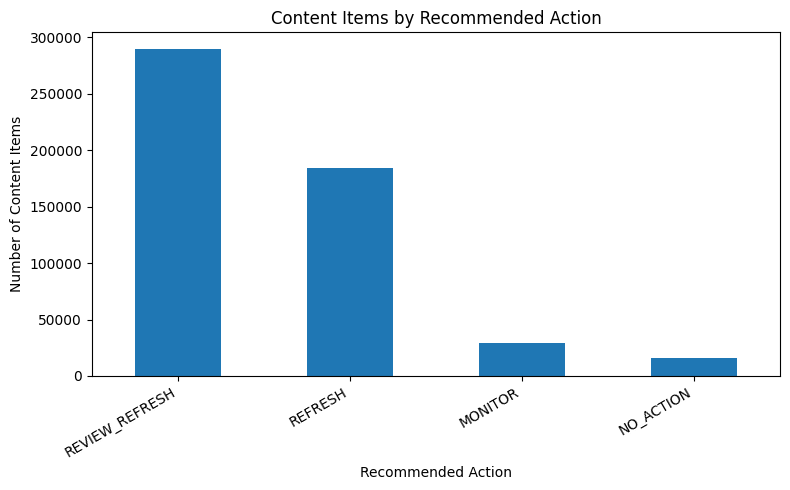

In [37]:
import matplotlib.pyplot as plt

action_counts = queue["action"].value_counts()

print("=== ACTION CATEGORY COUNTS ===")
print(action_counts)

plt.figure(figsize=(8, 5))
action_counts.plot(kind="bar")
plt.title("Content Items by Recommended Action")
plt.xlabel("Recommended Action")
plt.ylabel("Number of Content Items")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

=== ACTION CATEGORY COUNTS ===
action
REVIEW_REFRESH    289930
REFRESH           184280
MONITOR            29073
NO_ACTION          16323
Name: count, dtype: int64


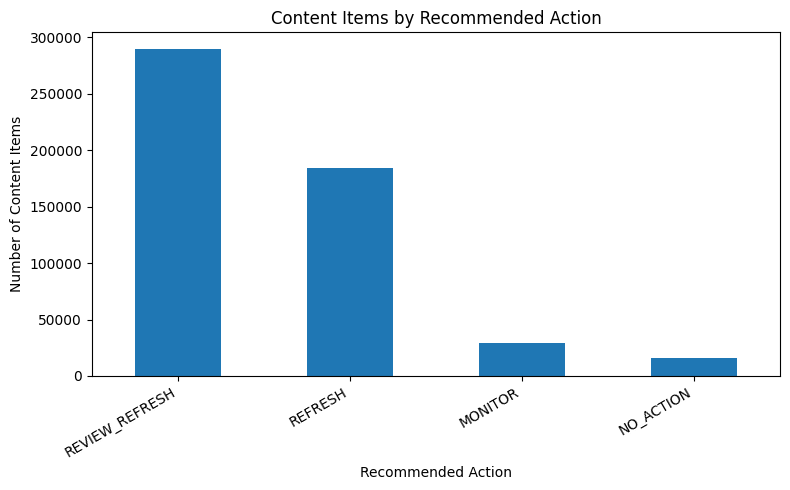

In [38]:
import matplotlib.pyplot as plt

action_counts = queue["action"].value_counts()

print("=== ACTION CATEGORY COUNTS ===")
print(action_counts)

plt.figure(figsize=(8, 5))
action_counts.plot(kind="bar")
plt.title("Content Items by Recommended Action")
plt.xlabel("Recommended Action")
plt.ylabel("Number of Content Items")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 8. Reproducibility

The analysis is implemented in the accompanying Jupyter notebooks in the repository. The capstone notebook documents the research question, data scope, methodology, validation approach, ranked recommendations, and supporting artifacts.

The baseline action queue is generated from the content table using the fixed decision date of June 30, 2026, recorded optimization date, and search volume. The Logistic Regression analysis uses a client-grouped held-out test set to reduce client-level leakage.

The notebooks can be rerun from the repository to reproduce the analysis, subject to access to the internship dataset and the same dataset release.


## 9. Acknowledgments & Data Credit

This work was completed as part of the FlyRank ML Internship. The analysis uses the FlyRank internship warehouse provided for the internship program.

The dataset is used only for the permitted internship analysis. Private client names, URLs, queries, credentials, and raw private exports are not included in this publication.

The findings are presented as observational and directional decision support. They should not be interpreted as causal evidence that a content refresh will improve search performance.


**                                  bold 5-minute demo outline  text**

## ML-12 — 5-Minute Demo Outline

### 1. Question — 45 seconds

Which content items show the strongest observable signals that they may be good candidates for refresh, and how can those signals help prioritize human review?

This question comes from the FlyRank content-refresh problem: deciding which pages deserve attention first when there are many content items to review.

### 2. Method — 1 minute

I used a simple rule-based baseline based on content staleness and search volume, and explored Logistic Regression as an interpretable ranking model.

For validation, I used an 80/20 grouped split by client so that content from the same client does not appear in both training and test sets.

I also performed leakage checks to avoid using target-derived or outcome-period information as model features.

### 3. One Chart — 1 minute

Show the **"Content Items by Recommended Action"** chart.

Explain that the chart shows how the content queue is distributed across REFRESH, REVIEW_REFRESH, MONITOR, and NO_ACTION categories.

### 4. One Honest Result — 1 minute

The analysis shows that simple observable signals such as content staleness and search demand can be used to create a practical prioritization queue.

The grouped validation design provides a more conservative evaluation than a standard random split because clients are kept separate.

This is directional evidence for prioritization, not proof that refreshing a page will cause better traffic or rankings.

### 5. One Recommendation — 1 minute 15 seconds

Start human review with **STALE_HIGH_VOLUME** pages because they combine long time since optimization with relatively high search demand.

Reviewers should then check search intent, current performance, content quality, freshness, and business relevance before making any change.

The model or score should support the decision — not make the decision automatically.

## ML-12 — Shareable Cuts

### Short Social Post

I built a content-refresh prioritization workflow using FlyRank's anonymized internship dataset.

Instead of treating a model score as a guaranteed SEO outcome, I focused on honest validation: a simple staleness + search-volume baseline, client-grouped evaluation, and leakage checks to make sure future or target-derived information was not used incorrectly.

The result is a practical decision-support workflow that ranks content for human review. The key lesson: in SEO, a useful model is not just about prediction — it is about using the available evidence carefully and being clear about what the data can and cannot prove.

### Employer-Facing Summary

I built a content-refresh prioritization workflow using the FlyRank internship warehouse, combining a rule-based baseline, interpretable ML methodology, grouped client-level validation, leakage checks, and a ranked action playbook. The analysis showed that observable signals such as content staleness and search demand can support practical prioritization of pages for human review, while avoiding unsupported causal claims about the effect of refreshing content. The final deliverable is a reproducible research notebook and public-safe research paper that turns the analysis into actionable recommendations.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
